In [ ]:
# ── MLOps bootstrap (auto-injected by inject_mlops_cell.py) ──────────────────
import os, warnings, mlflow
warnings.filterwarnings("ignore")

SEED = 42
import random, numpy as np
random.seed(SEED)
np.random.seed(SEED)
try:
    import torch; torch.manual_seed(SEED)
except ImportError:
    pass
try:
    import tensorflow as tf; tf.random.set_seed(SEED)
except ImportError:
    pass

_nb_name = os.path.basename(os.path.abspath("__file__") if "__file__" in dir() else ".").replace(".ipynb","")
mlflow.set_tracking_uri("sqlite:///" + str(Path(__file__).parent.parent.parent / "mlflow.db")
                        if "__file__" in dir() else "sqlite:///mlflow.db")
_exp = mlflow.set_experiment(_nb_name or "unnamed_notebook")
print(f"MLflow experiment: {_exp.name}")


# Character-Level Language Model with GRU

Trains a character-level recurrent network on Shakespeare text to learn to generate English sentences.  
Demonstrates RNN sequence modelling using TensorFlow/Keras GRU (CPU-compatible, no GPU required).

Original concept from: https://www.kaggle.com/anilreddy8989/word-guess-with-rnn  
Rewritten to use TF2 native APIs and a publicly downloadable dataset.

In [1]:
import urllib.request
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from pathlib import Path

print(f'TensorFlow {tf.__version__}')
gpus = tf.config.list_physical_devices('GPU')
print(f'GPUs available: {len(gpus)} ({gpus[0].name if gpus else "CPU only"})')

C:\Users\ahmad\AppData\Local\Programs\Python\Python313\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.0.post2)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


TensorFlow 2.21.0


GPUs available: 0 (CPU only)


In [2]:
# Download Shakespeare text (~1 MB corpus hosted by TensorFlow)
DATA_URL = 'https://storage.googleapis.com/download.tensorflow.org/data/shakespeare.txt'
cache_path = Path('shakespeare.txt')

if not cache_path.exists():
    print('Downloading Shakespeare corpus...')
    urllib.request.urlretrieve(DATA_URL, cache_path)
    print(f'Saved to {cache_path}')
else:
    print(f'Using cached {cache_path}')

text = cache_path.read_text(encoding='utf-8')
print(f'Corpus length : {len(text):,} characters')
print('Sample text   :', repr(text[:200]))

Using cached shakespeare.txt
Corpus length : 1,115,394 characters
Sample text   : 'First Citizen:\nBefore we proceed any further, hear me speak.\n\nAll:\nSpeak, speak.\n\nFirst Citizen:\nYou are all resolved rather to die than to famish?\n\nAll:\nResolved. resolved.\n\nFirst Citizen:\nFirst, you'


In [3]:
# Build character-level vocabulary
vocab = sorted(set(text))
vocab_size = len(vocab)
print(f'Unique characters: {vocab_size}')
print('Vocabulary:', vocab)

char2idx = {c: i for i, c in enumerate(vocab)}
idx2char = np.array(vocab)

# Encode the full text as integer indices
text_encoded = np.array([char2idx[c] for c in text], dtype=np.int32)
print(f'\nEncoded array shape: {text_encoded.shape}')
print('First 20 chars :', repr(text[:20]))
print('Encoded as     :', text_encoded[:20])

Unique characters: 65
Vocabulary: ['\n', ' ', '!', '$', '&', "'", ',', '-', '.', '3', ':', ';', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']

Encoded array shape: (1115394,)
First 20 chars : 'First Citizen:\nBefor'
Encoded as     : [18 47 56 57 58  1 15 47 58 47 64 43 52 10  0 14 43 44 53 56]


In [4]:
# Create (input, target) sequence pairs for training
SEQ_LEN     = 100     # length of each training sequence
BATCH_SIZE  = 64
BUFFER_SIZE = 10_000  # shuffle buffer

char_dataset = tf.data.Dataset.from_tensor_slices(text_encoded)
sequences    = char_dataset.batch(SEQ_LEN + 1, drop_remainder=True)

def split_input_target(chunk):
    """Offset target by 1: model learns to predict the *next* character."""
    return chunk[:-1], chunk[1:]

dataset = (
    sequences
    .map(split_input_target)
    .shuffle(BUFFER_SIZE)
    .batch(BATCH_SIZE, drop_remainder=True)
    .prefetch(tf.data.AUTOTUNE)
)

# Verify shapes
for x_batch, y_batch in dataset.take(1):
    print(f'Input  shape: {x_batch.shape}')   # (64, 100)
    print(f'Target shape: {y_batch.shape}')   # (64, 100)
    seq = x_batch[0].numpy()
    print(f'Sample input : {repr("".join(idx2char[seq[:50]]))}')
    print(f'Sample target: {repr("".join(idx2char[y_batch[0].numpy()[:50]]))}')

Input  shape: (64, 100)
Target shape: (64, 100)
Sample input : 'f, a little help\nwill serve; for once we stood up '
Sample target: ', a little help\nwill serve; for once we stood up a'


In [5]:
# Build a character-level GRU model (CPU-compatible — no CuDNN required)
EMBEDDING_DIM = 128
GRU_UNITS     = 512

model = tf.keras.Sequential([
    tf.keras.layers.Embedding(vocab_size, EMBEDDING_DIM, name='embedding'),
    tf.keras.layers.GRU(
        GRU_UNITS,
        return_sequences=True,
        reset_after=True,   # standard implementation that works on CPU and GPU
        name='gru'
    ),
    tf.keras.layers.Dense(vocab_size, name='logits')
], name='char_lm')

model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
)

model.summary()

Model: "char_lm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ logits (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Train the model
EPOCHS = 10

history = model.fit(dataset, epochs=EPOCHS, verbose=1)

print(f'\nInitial loss : {history.history["loss"][0]:.4f}')
print(f'Final loss   : {history.history["loss"][-1]:.4f}')

Epoch 1/10


  1/172 ━━━━━━━━━━━━━━━━━━━━ 10:05 4s/step - loss: 4.1746

  2/172 ━━━━━━━━━━━━━━━━━━━━ 44s 262ms/step - loss: 4.1680

  3/172 ━━━━━━━━━━━━━━━━━━━━ 44s 263ms/step - loss: 4.1601

  4/172 ━━━━━━━━━━━━━━━━━━━━ 43s 260ms/step - loss: 4.1496

...

170/172 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - loss: 1.3235

171/172 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - loss: 1.3235

172/172 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - loss: 1.3235

172/172 ━━━━━━━━━━━━━━━━━━━━ 41s 231ms/step - loss: 1.3270



Initial loss : 2.6303
Final loss   : 1.3270


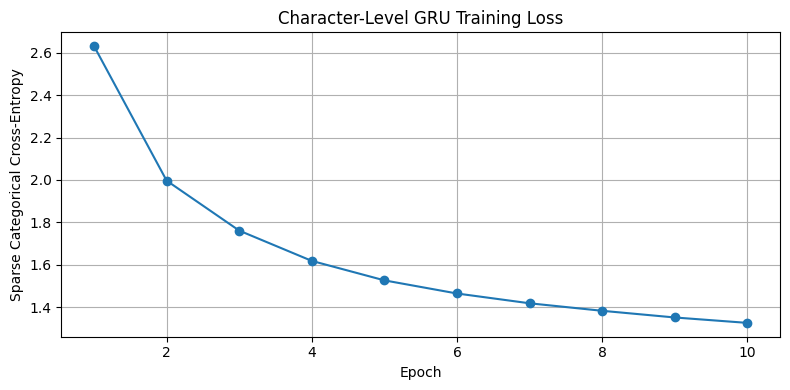

In [7]:
# Plot training loss
plt.figure(figsize=(8, 4))
plt.plot(range(1, EPOCHS + 1), history.history['loss'], marker='o')
plt.title('Character-Level GRU Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Sparse Categorical Cross-Entropy')
plt.grid(True)
plt.tight_layout()
plt.show()

In [8]:
# Generate text from the trained model (auto-regressive sampling)
# Uses a growing-sequence approach compatible with Keras 3 (TF 2.16+)

def generate_text(model, start_string, num_generate=400, temperature=1.0):
    """Generate characters auto-regressively from a seed string."""
    # Encode seed (skip any characters not in vocabulary)
    generated_ids = [char2idx[c] for c in start_string if c in char2idx]

    for _ in range(num_generate):
        # Feed the full generated sequence each step
        input_ids = tf.expand_dims(generated_ids, 0)        # (1, seq_len)
        logits    = model(input_ids, training=False)         # (1, seq_len, vocab_size)
        last_logit = logits[0, -1, :] / temperature          # last timestep
        pred_id   = tf.random.categorical(
            tf.expand_dims(last_logit, 0), num_samples=1
        )[0, 0].numpy()
        generated_ids.append(int(pred_id))

    return ''.join(idx2char[generated_ids])

print('=== Generated text (temperature=1.0 — creative) ===')
print(generate_text(model, 'ROMEO: ', num_generate=400, temperature=1.0))
print()
print('=== Generated text (temperature=0.5 — conservative) ===')
print(generate_text(model, 'JULIET: ', num_generate=200, temperature=0.5))

=== Generated text (temperature=1.0 — creative) ===


ROMEO: I kid,
That's love, do once for a montherood of widow
By Hastings thousan will dispips of monkary;
Therefore for this father's father?

DUKE VINCENTIO:
I am no ground! whither
Datest me your grace with the roabfo:
O thronging, sir; need her spectate met,
And comes runaly and unsallukent Hortension
Mancell'd profiting sorry shurs:
Wave Edward's almost; we here at himself;
Furn By my queen's, which 

=== Generated text (temperature=0.5 — conservative) ===


JULIET: the people of the state
And honour the law to be too falling in this?

FLORIZEL:
Why, he hath some son I'll ask your grace for the earth.
And that no man that all the father would have been
The crown 
